No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


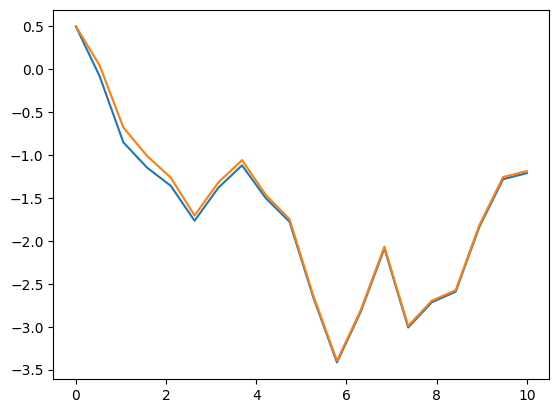

In [1]:
import jax
import jax.numpy as jnp

from probjax.utils.sdeint import sdeint


# Define the ODE
def f(x, t):
    return -x**t

def g(x, t):
    return 0.5

# Define the initial condition
x0 = jnp.ones((1,))*0.5

# Define the time points to evaluate
t = jnp.linspace(0., 10., 20)

# Solve the ODE
key = jax.random.PRNGKey(0)
x = sdeint(key, f, g, x0, t, method="srk3(2)")
x2 = sdeint(key, f, g, x0, t)



# Plot the solution
import matplotlib.pyplot as plt
plt.plot(t, x)
plt.plot(t, x2)

In [6]:
from probjax.distributions.sde import BaseSDE, LinearTimeInvariantSDE, matrix_fraction_decomposition, VESDE, VPSDE
from probjax.distributions import Normal, Dirac, Empirical
target_samples1 = Normal(-2, 0.1).sample(key, (1000,))
target_samples2 = Normal(2, 0.1).sample(key + 1, (1000,))
target_samples = jnp.concatenate([target_samples1, target_samples2])

p0 = Dirac(target_samples)
#p0 = Empirical(target_samples, jnp.ones((2000,)) / 2000)
#p0 = Normal(jnp.array(0.5), jnp.array(1.))


In [7]:
p = VESDE(p0)
t = jnp.linspace(0., 1., 100)
ys = p.sample(key, t, ((10,)), method="srk3(2)")
mus = p.mean(t, x0=target_samples)
std = jnp.sqrt(p.variance(t,x0 = target_samples))

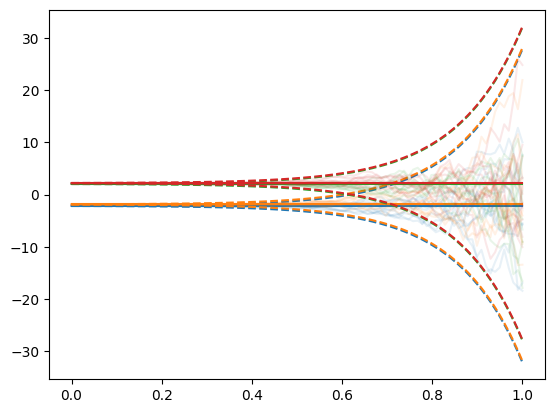

In [8]:
for i in range(4):
    j = i * 500
    _ = plt.plot(t,ys[:, :, j].T, color=f"C{i}", alpha=0.1)
    _ = plt.plot(t, mus[:, j], color=f"C{i}")
    _ = plt.plot(t, mus[:,j]+3*std[:, j], color=f"C{i}", linestyle="--")
    _ = plt.plot(t, mus[:, j]-3*std[:,j], color=f"C{i}", linestyle="--")

In [9]:
p = VPSDE(p0)
t = jnp.linspace(0., 1., 100)
ys = p.sample(key, t, (100,), method="srk3(2)")
mus = p.mean(t)
std = jnp.sqrt(p.variance(t))

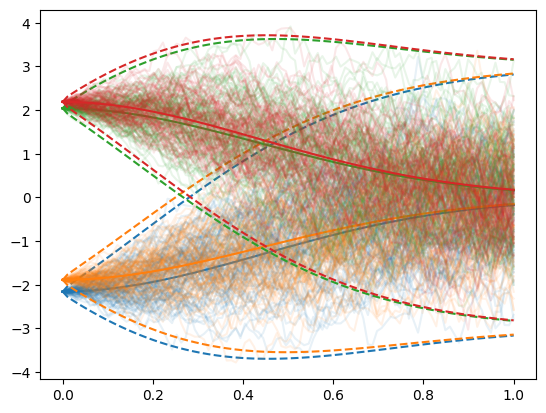

In [10]:
for i in range(4):
    j = i * 500
    _ = plt.plot(t,ys[:, :, j].T, color=f"C{i}", alpha=0.1)
    _ = plt.plot(t, mus[:, j], color=f"C{i}")
    _ = plt.plot(t, mus[:,j]+3*std[:, j], color=f"C{i}", linestyle="--")
    _ = plt.plot(t, mus[:, j]-3*std[:,j], color=f"C{i}", linestyle="--")

In [38]:
score_fn = jax.grad(lambda x, t: p.log_prob(x, t).sum())(jnp.ones((2000,)),jnp.ones((1,)))

(1, 2000)
(1, 2000)
(2000,)


In [22]:
p.log_prob(jnp.ones((2000,)), jnp.ones((1,)))

(1, 2000)
(1, 2000)
(2000,)


Array([[-2.57 , -2.556, -2.549, ..., -0.933, -0.934, -0.937]], dtype=float32)

In [ ]:
from typing import Callable

def filter(drift: Callable, diffusion: Callable, mu0, cov0, ts, t_o = None, y_o = None, C_o = None, R_o = None, method="ode"):

    mu0 = jnp.atleast_1d(mu0)
    cov0 = jnp.atleast_2d(cov0)
    ts = jnp.atleast_1d(ts)
    dtype = mu0.dtype
    # Check consistent shapes
    assert mu0.shape[0] == cov0.shape[0] == cov0.shape[1], "Dimension mismatch, cov0 must be a square matrix of shape (d,d) and mu0 must be a vector of shape (d,)"

    # Consistent dtype
    cov0 = cov0.astype(dtype)
    ts = ts.astype(dtype)
    _drift = lambda t,x: jnp.atleast_1d(drift(t, x)).astype(dtype)
    _diffusion = lambda t, x: jnp.atleast_2d(diffusion(t,x)).astype(dtype)

    # If we condition on observations
    if t_o is None:
        assert y_o is None, "If t_o is not provided, y_o must not be provided"
        ts_merged = ts
        observed_index_array = jnp.zeros(len(ts_merged), dtype=jnp.int32)
    else:
        index_observed = jnp.searchsorted(ts, t_o)
        ts_merged = jnp.insert(ts, index_observed, t_o)
        index_observed = jnp.searchsorted(ts_merged, t_o)
        observed_mask_array = jnp.zeros(len(ts_merged), dtype=jnp.int32).at[index_observed].set(1)
        observed_index_array = observed_mask_array.cumsum()

    





In [17]:
A = jnp.array([[-0.5]])

def drift(t, x):
    return jnp.matmul(A, x)

@jax.jit
def jac(t, x):
    return A 

jac_jax = jax.jit(jax.jacfwd(drift, argnums=1))

In [19]:
%%timeit 
jac(0., jnp.ones((1,)))

287 µs ± 3.57 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [20]:
%%timeit 
jac_jax(0., jnp.ones((1,)))

98.4 µs ± 1.44 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [ ]:
def predict_linear_ode(t, data, A, B):
    mu0, cov0 = data
    mu = jnp.dot(A, mu0)
    cov = jnp.dot(A, cov0) + jnp.dot(cov0, A.T) + jnp.dot(B, B.T)
    return mu, cov

In [13]:
_predict(0. ,0.1, jnp.ones(1), jnp.ones(1))

(Array([0.951], dtype=float32), Array([[0.929]], dtype=float32))

In [14]:
from probjax.inference.kalman_filter import kalman_filter, predict_discrete, update
from functools import partial
_predict = partial(predict_discrete, drift_matrix = lambda x,t: jnp.array([[-0.5]]), diffusion_matrix = lambda x,t: jnp.array([[0.5]]))
kalman_filter(t, jnp.ones(1)*0.5,jnp.eye(1), _predict, update,  jnp.array([0.5]), jnp.array([0.5]), jnp.array([[1.]]), jnp.array([[1.]]))

(Array([[0.5  ],
        [0.435],
        [0.429],
        [0.33 ],
        [0.254],
        [0.195],
        [0.15 ],
        [0.115],
        [0.089],
        [0.068],
        [0.052],
        [0.04 ],
        [0.031],
        [0.024],
        [0.018],
        [0.014],
        [0.011],
        [0.008],
        [0.006],
        [0.005],
        [0.004]], dtype=float32),
 Array([[[1.   ]],
 
        [[0.413]],
 
        [[0.409]],
 
        [[0.344]],
 
        [[0.306]],
 
        [[0.283]],
 
        [[0.269]],
 
        [[0.261]],
 
        [[0.257]],
 
        [[0.254]],
 
        [[0.252]],
 
        [[0.251]],
 
        [[0.251]],
 
        [[0.25 ]],
 
        [[0.25 ]],
 
        [[0.25 ]],
 
        [[0.25 ]],
 
        [[0.25 ]],
 
        [[0.25 ]],
 
        [[0.25 ]],
 
        [[0.25 ]]], dtype=float32),
 Array([[0.5  ],
        [0.389],
        [0.429],
        [0.33 ],
        [0.254],
        [0.195],
        [0.15 ],
        [0.115],
        [0.089],
        [0.068],


In [31]:
?kalman_filter

Signature:
kalman_filter(
    ts: jax.Array,
    mu0: jax.Array,
    cov0: jax.Array,
    predict: Callable,
    update: Callable,
    t_o: jax.Array,
    y_o: jax.Array,
    C_o: jax.Array,
    R_o: jax.Array,
) -> Tuple[jax.Array, jax.Array, jax.Array, jax.Array]
Docstring:
Kalman filter for a discrete time model on time grid ts.

Args:
    ts (Array): Time grid to filter on.
    mu0 (Array): Starting mean
    cov0 (Array): Starting covariance
    predict (Callable): Prediction function
    update (Callable): Update function
    t_o (Array): Observation times
    y_o (Array): Observation values
    C_o (Array): Observation projection matrix
    R_o (Array): Observation noise covariance matrix

Returns:
    Tuple[Array, Array, Array, Array]: Mean and covs at observation times, and mean and covs at all times.
File:      /mnt/c/Users/manug/OneDrive/Uni/PHD/probjax/probjax/inference/kalman_filter.py
Type:      function

In [25]:
_sdeint = partial(sdeint, self.drift, self.diffusion, **kwargs)
shape = ts.shape + sample_shape + self.batch_shape + self.event_shape
key1, key2 = jax.random.split(key)
x0 = self.p0.sample(key1, sample_shape)
x0_flat = x0.reshape(-1, *self.event_shape)
ys = sdeint(self.drift, self.diffusion, x0, ts, **kwargs)

NameError: name 'self' is not defined

In [38]:
from functools import partial
kwargs = {"method": "euler_maruyama"}
_sdeint = partial(sdeint, **kwargs)
_sdeint = jax.vmap(_sdeint, in_axes=(0,None,None, 0,None))
key = jax.random.split(key, 100)
x0 = x0.repeat(100, axis=0).reshape(100, 1)
ys = _sdeint(key, f,g, x0, t)

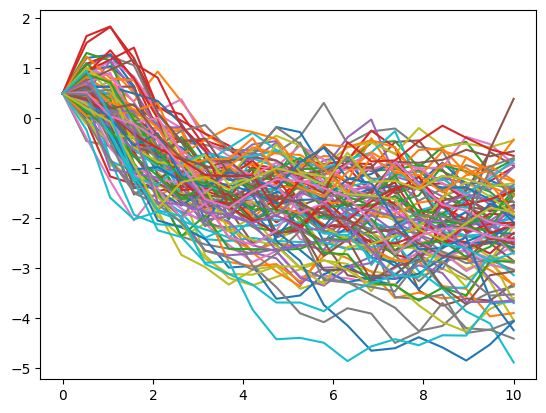

In [39]:
_ = plt.plot(t, jnp.squeeze(ys).T)

In [39]:
B = jnp.ones((3, 2, 2))
c = jnp.array([0.3333,0.3333, 0.3333])

jnp.einsum("ijk,i->jk", B, c)


Array([[0.9999, 0.9999],
       [0.9999, 0.9999]], dtype=float32)

In [40]:
jnp.einsum("i,i -> i", c, c)

Array([0.11108889, 0.11108889, 0.11108889], dtype=float32)

In [42]:
jnp.ones((3,2)) @ jnp.ones((2,))

Array([2., 2., 2.], dtype=float32)

In [26]:
?jnp.dot

Signature:      jnp.dot(a, b, *, precision=None)
Call signature: jnp.dot(*args, **kwargs)
Type:           PjitFunction
String form:    <PjitFunction of <function dot at 0x7fed84bc0f70>>
File:           ~/miniconda3/envs/rvtorch/lib/python3.10/site-packages/jax/_src/numpy/lax_numpy.py
Docstring:     
Dot product of two arrays. Specifically,

LAX-backend implementation of :func:`numpy.dot`.

In addition to the original NumPy arguments listed below, also supports
``precision`` for extra control over matrix-multiplication precision
on supported devices. ``precision`` may be set to ``None``, which means
default precision for the backend, a :class:`~jax.lax.Precision` enum value
(``Precision.DEFAULT``, ``Precision.HIGH`` or ``Precision.HIGHEST``) or a tuple
of two :class:`~jax.lax.Precision` enums indicating separate precision for each argument.

*Original docstring below.*

- If both `a` and `b` are 1-D arrays, it is inner product of vectors
  (without complex conjugation).

- If both `a` a

In [13]:
c.shape

(3,)

In [40]:
from functools import partial

def f(x, t, a):
    return a*x

g = partial(f, a=0.1)

g.keywords["a"] = 0.2

In [41]:
g.

functools.partial(<function f at 0x7f76b47168c0>, a=0.2)

In [12]:
from probjax.core import inverse, inverse_and_logabsdet

def g(x0):
    ys = odeint(f, x0, t, method="bosh3")
    y1 = ys[-1]
    return y1

y1 = g(jnp.ones((1,)))
g_inv = inverse(g)

jaxpr = jax.make_jaxpr(g)(jnp.ones((1,)))

In [20]:
jaxpr.eqns[-2]

a:f32[1,1] = dynamic_slice[slice_sizes=(1, 1)] b c d

In [4]:
logdet

Array(1.524, dtype=float32)

In [22]:
f(x0, t[0])

Array([-1., -1.], dtype=float32)

In [21]:
# def _inv_logdet_odeint(drift, y0, ts, *args, **kwargs):
#     drift_jac = jax.jacobian(drift, argnums=1)

#     def aug_drift(t, x, *args):
#         print("X",x.shape)
#         x = x[:-1]
#         x_new = drift(t, x, *args)
#         jac = drift_jac(t, x, *args)
#         print(jac.shape)
#         if jac.ndim > 2:
#             logdet_new = jnp.diagonal(jac, axis1=-2, axis2=-1).sum().reshape((1,))
#         else:
#             logdet_new = jac.sum().reshape((1,))

#         return jnp.concatenate([x_new, logdet_new])

#     y0_extended = jnp.concatenate([y0, jnp.zeros((1,))])
#     print(y0_extended.shape)
#     ys_extended = odeint(aug_drift, y0_extended, ts, *args, **kwargs)
#     ys = ys_extended[:, :-1]
#     logdet = ys_extended[-1, -1]

#     return ys, logdet

# with jax.disable_jit():
#     _inv_logdet_odeint(f, x0, t, method="euler")

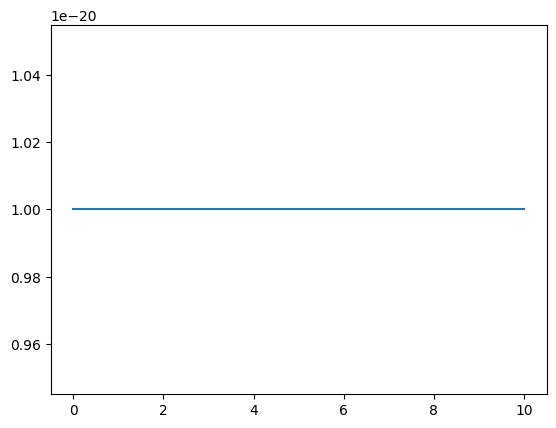

In [3]:
ys = odeint(f, x0*1e-20, t[::-1], method="heun_euler")

plt.plot(t, ys[::-1])

# ys = odeint(lambda x,t : f(-x, t), x0*1e-20, t, method="rk3(2)")
# plt.plot(t, ys)

In [ ]:
from jax import lax
from typing import Callable, Tuple, Union
from jax import Array

def explicit_stochastic_runge_kutta_step(
    drift: Callable,
    diffusion: Callable,
    t0: Array,
    y0: Array,
    f0: Array,
    g0: Array,
    dt: Array,
    dWt: Array,
    dWtdWs: Array,
    c0: Array,
    c1: Array,
    A0: Array,
    A1: Array,
    B0: Array,
    B1: Array,
    b_sol: Array,
    gamma0: Array,
    gamma1: Array,
    b_error: Array,
    order: int,
):
    def body_fun(i, k1, k2):
        ti1 = t0 + dt * c0[i - 1]
        ti2 = t0 + dt * c1[i - 1]

        yi1 = y0 + dt.astype(f0.dtype) * jnp.dot(A0[i - 1, :], k1) + dWt * jnp.dot(B1[i - 1, :], k2)
        yi2 = y0 + dt.astype(f0.dtype) * jnp.dot(A1[i - 1, :], k1) + jnp.sqrt(dt) * jnp.dot(B1[i - 1, :], k2)

        ft = drift(yi1, ti1)
        gt = diffusion(yi2, ti2)
        return k1.at[i, :].set(ft), k2.at[i, :].set(gt)

    k1 = jnp.zeros((order, f0.shape[0]), f0.dtype).at[0, :].set(f0)
    k2 = jnp.zeros((order, f0.shape[0]), f0.dtype).at[0, :].set(f0)
    k1,k2 = lax.fori_loop(1, order, body_fun, k1, k2)

    y1 = y0 + dt.astype(f0.dtype) * jnp.dot(b_sol, k1) + dWt * jnp.dot(gamma0, k2) + dWtdWs * jnp.dot(gamma1, k2)
    f1 = k1[-1]
    g1 = k2[-1]

    if b_error is None:
        y1_error = None
    else:
        raise NotImplementedError

    return y1, f1,g1, (y1_error, k1,k2)

euler


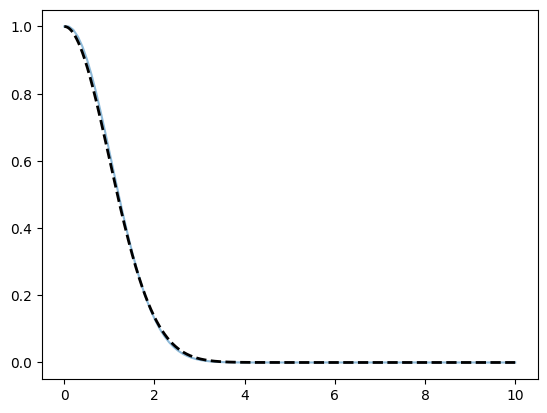

heun


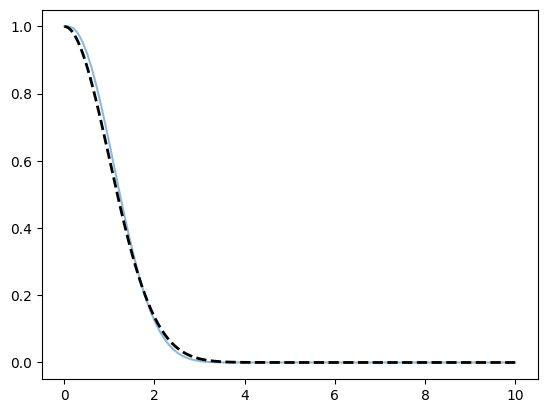

heun_euler


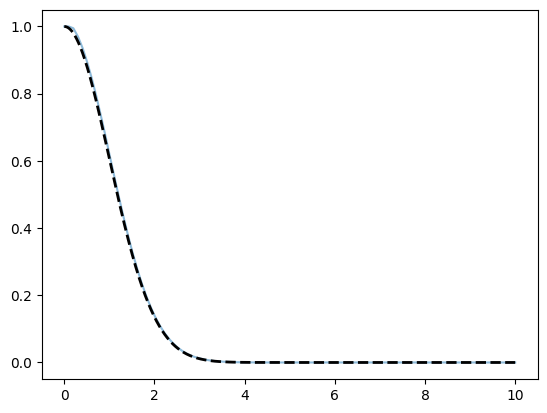

midpoint


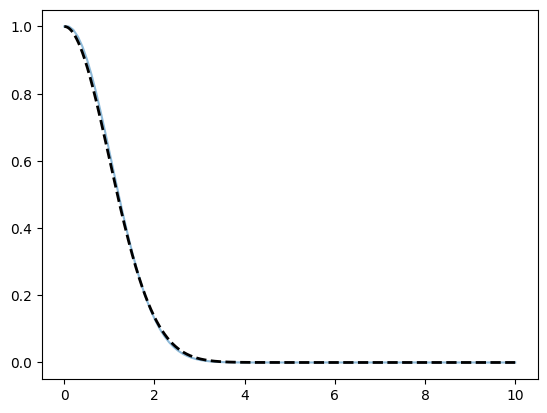

ralston


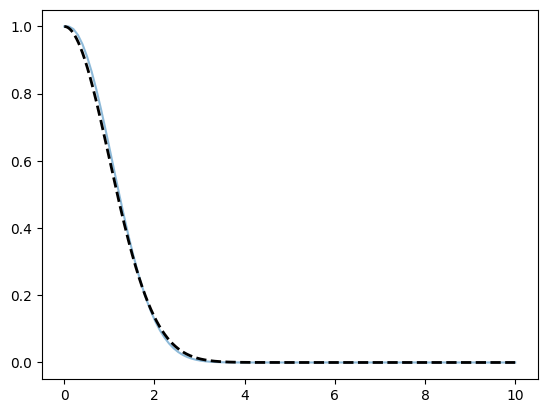

rk3


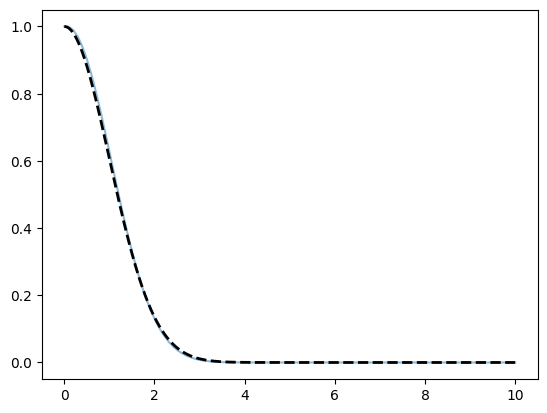

rk3(2)


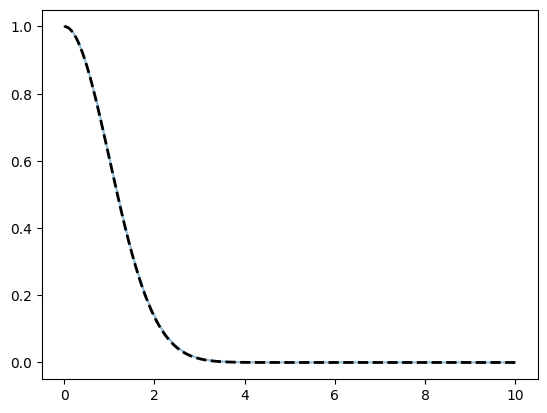

bosh3


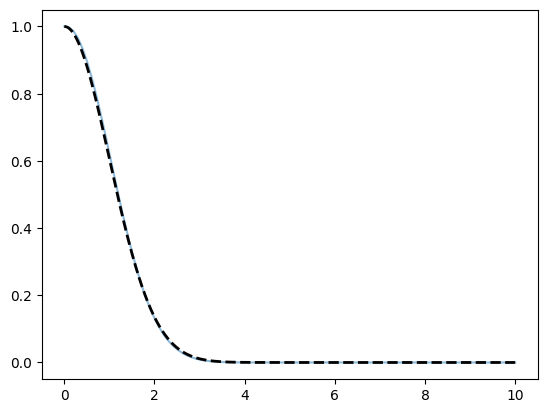

heun3


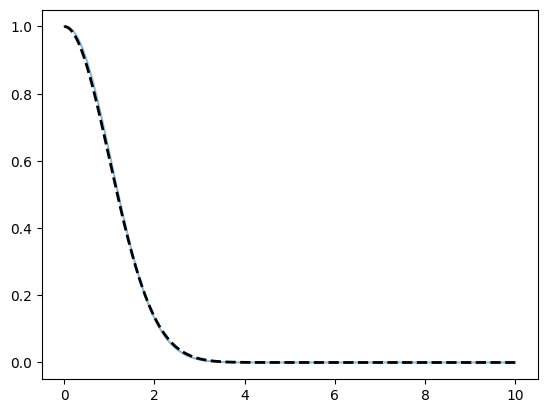

vanderhouwen


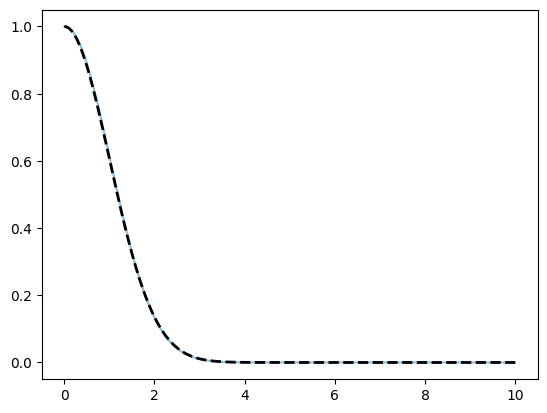

ralston3


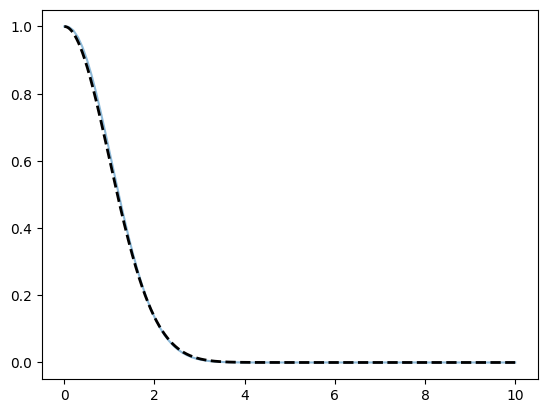

ssprk3


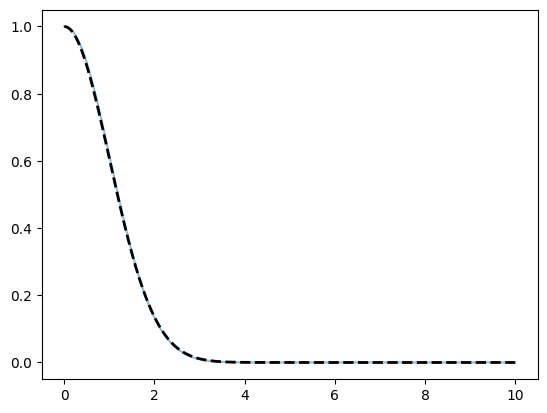

rk4


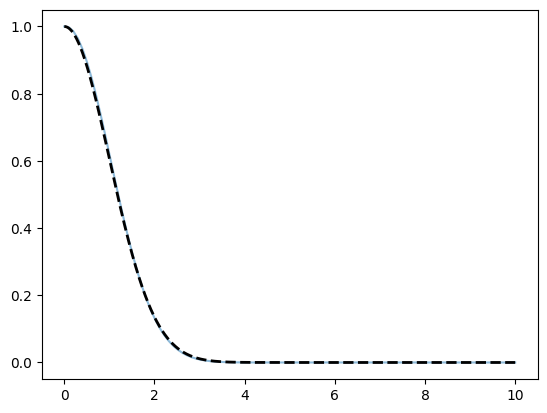

rk4(5)


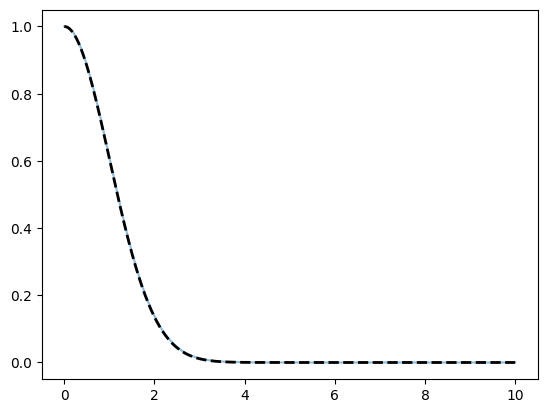

3/8


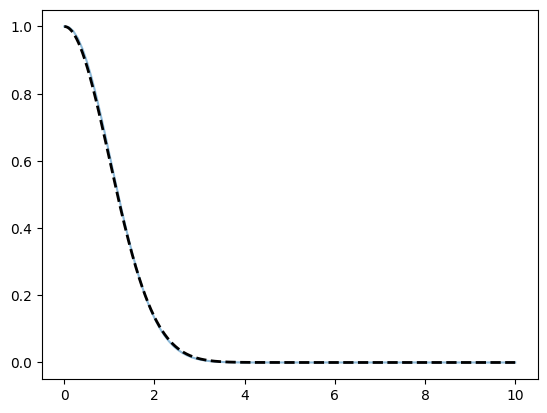

ralston4


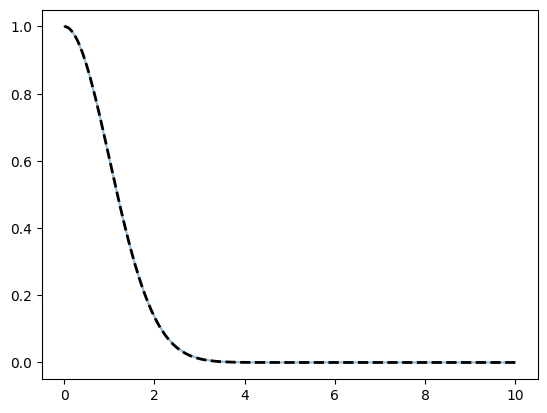

rk5(4)


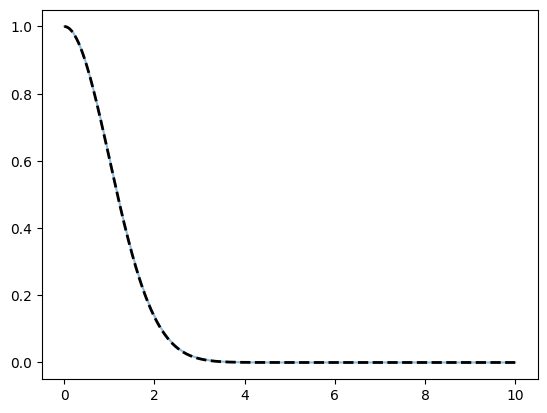

dopri5


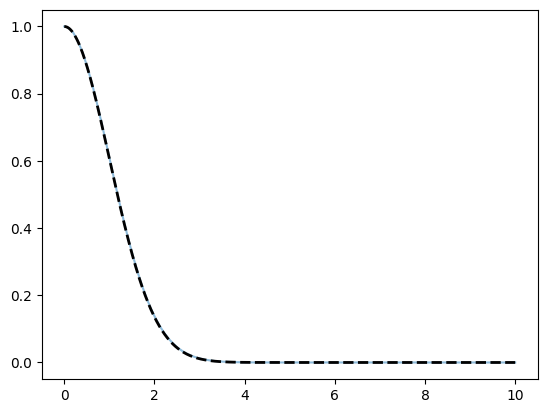

implicit_euler


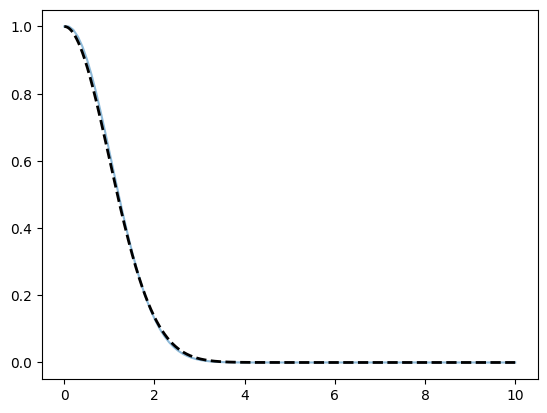

implicit_midpoint


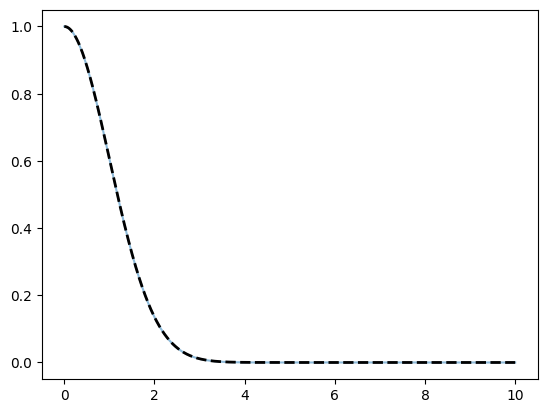

implicit_trapezoidal


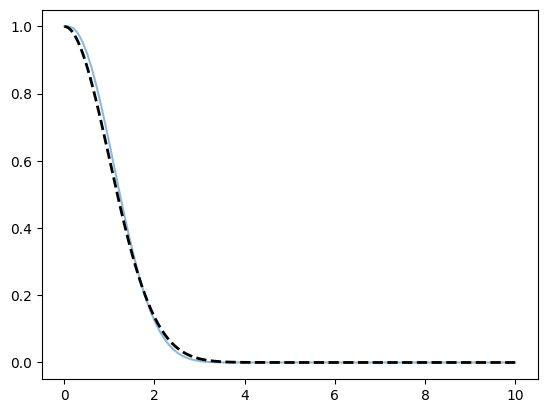

implicit_crank_nicolson


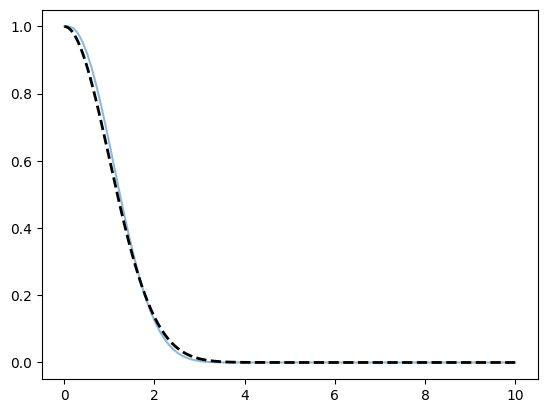

gauss_legendre


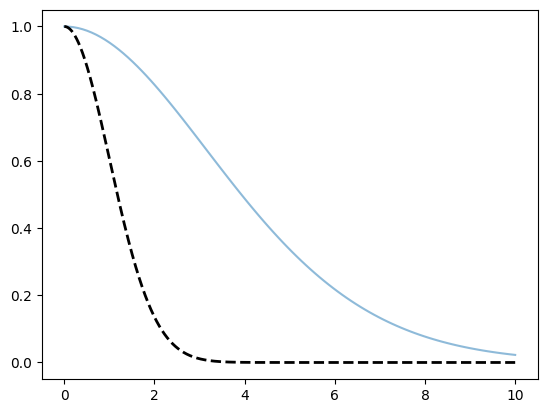

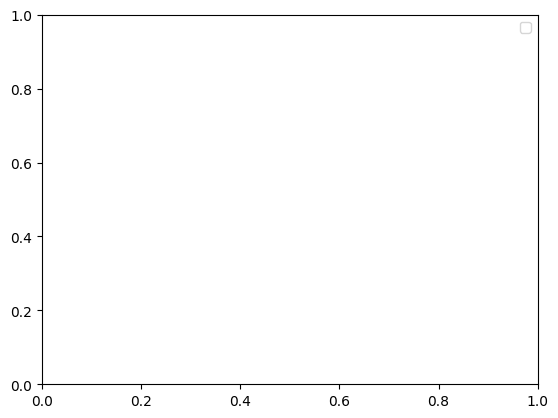

In [8]:
# odeint for all methods
from probjax.utils.odeint import odeint, get_methods

METHODS = get_methods()

for m in METHODS:
    print(m)
    #with jax.disable_jit():
    x = odeint(f, x0, t, method=m)
    
    plt.plot(t, x, label=m, alpha=0.5)
    plt.plot(jnp.linspace(0, 10, 10000), odeint(f, x0, jnp.linspace(0, 10, 10000), method="rk4"), color="black", lw=2, linestyle="--")
    plt.show()



plt.legend(METHODS + ["True"])

In [23]:
def f(x):
    return x**2 - 2

In [34]:
jnp.finfo(jnp.float32).eps

1.1920929e-07

In [37]:
from jax import lax
from functools import partial

METHODS = {}


c0 = jnp.array([0., 1.])
A0 = jnp.array([[0., 0.], [1., 0.]])
b_sol = jnp.array([0.5, 0.5])
b_error = jnp.array([1., 0.])

@partial(jax.jit, static_argnums=(0,))
def runge_kutta_step(func, y0, f0, t0, dt, c, A, b_sol, b_error, order=2):
  # Dopri5 Butcher tableaux

  def body_fun(i, k):
    ti = t0 + dt * c[i-1]
    yi = y0 + dt.astype(f0.dtype) * jnp.dot(A[i-1, :], k)
    ft = func(yi, ti)
    return k.at[i, :].set(ft)

  k = jnp.zeros((order, f0.shape[0]), f0.dtype).at[0, :].set(f0)
  k = lax.fori_loop(1, order, body_fun, k)

  y1 = dt.astype(f0.dtype) * jnp.dot(b_sol, k) + y0
  y1_error = dt.astype(f0.dtype) * jnp.dot(b_error, k)
  f1 = k[-1]
  return y1, f1, y1_error, k

In [52]:
jnp.linalg.is_tril(A0)

AttributeError: module 'jax.numpy.linalg' has no attribute 'is_tril'

In [44]:
%%timeit
runge_kutta_step(f, jnp.array([1.]), jnp.array([1.]), jnp.array([0.]), jnp.array([1.]), alpha, beta, c_sol, c_error)

424 µs ± 16.8 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [47]:
@partial(jax.jit, static_argnums=(0,))
def _heun_step(_f, t0, y0, dt):
    half_dt = dt / 2
    k1 = _f(t0, y0)
    k2 = _f(t0 + half_dt, y0 + half_dt * k1)
    return y0 + (k1 + k2)/2 * dt

In [51]:
%%timeit
_heun_step(f, jnp.array([0.]), jnp.array([1.]), jnp.array([1.]))

293 µs ± 23.9 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [29]:
def newton_raphson(f, x0, tol=1e-6, max_iter=50):
    """
    Newton-Raphson root-finding algorithm for a vector-valued function.
    
    Args:
    - f: A function that takes a vector x and returns a vector of the same shape.
    - x0: Initial guess for the root.
    - tol: Tolerance for stopping criterion (default: 1e-6).
    - max_iter: Maximum number of iterations (default: 100).
    
    Returns:
    - x: The estimated root of the function.
    """
    x = x0

    f_jax = jax.jacobian(f)

    def scan_fn(carry, i):
        tol_reached, x = carry

        def true_fn(x):
            return x, jnp.inf

        def false_fn(x):
            y = f(x)
            J = f_jax(x)
            delta_x = jax.scipy.linalg.solve(J, -y)
            x = x + delta_x
            return x, jnp.linalg.norm(delta_x)
        
        
        x, delta_x = jax.lax.cond(tol_reached, true_fn, false_fn, x)
        tol_reached = delta_x < tol
        return (tol_reached, x), x
      
    
    tol_reached = False
    _, x = jax.lax.scan(scan_fn, (tol_reached, x), jnp.arange(max_iter))
    return x[-1]

newton_raphson(f, jnp.array([100.]))

Array([1.414], dtype=float32)

In [30]:
from probjax.utils.interpolation import linear_interpolation

jax.vmap(linear_interpolation(t, x))(jnp.array([0.5, 0.75])).shape

(2, 1)

In [20]:

from functools import partial
from typing import Optional, Tuple, Union
from jax import Array 
from jaxtyping import Float


jax.jit
def _generate_grid(ts: jnp.ndarray, dt_max: Optional[float] = None):
    """Generate a grid of time points that satisfy the minimum dt

    Args:
        ts (jnp.ndarray): Time points.
        max_dt (Optional[float], optional): Maximum dt. Defaults to None.

    Returns:
        jnp.ndarray: Grid of time points.
    """
    dts = ts[1:] - ts[:-1]
    dts_expension = jnp.ceil(dts / dt_max)

    def scan_fn(t_prev, dt):
        def true_fn(dt):
            return t_prev + dt
        
        def false_fn(dt):
            
            def cond_fn(t):
                return t < t_prev + dt
            
            def body_fn(t):
                return t + dt
            
            return jax.lax.while_loop(cond_fn, body_fn, t_prev)
        return t, grid
    
    _, grid = jax.lax.scan(scan_fn, (ts[0],), dts)
    

In [33]:
dt_max = 0.1
ts = jnp.array([0.0, 0.1, 0.35,0.5])
dts  = ts[1:] - ts[:-1]

dts_extension = jnp.ceil(dts/dt_max)

dts_extension

Array([1., 3., 2.], dtype=float32)

In [26]:
@jax.jit 
def f(ts):
    T_max = ts[-1]
    T_min = ts[0]
    ts = _generate_grid(ts, T_max, T_min, max_dt=0.1)

In [27]:
f(t)

ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: Traced<ShapedArray(float32[])>with<DynamicJaxprTrace(level=2/0)>
The problem arose with the `int` function. If trying to convert the data type of a value, try using `x.astype(int)` or `jnp.array(x, int)` instead.
The error occurred while tracing the function _generate_grid at /tmp/ipykernel_10811/4238015521.py:7 for jit. This value became a tracer due to JAX operations on these lines:

  operation a:f32[] = sub b c
    from line /tmp/ipykernel_10811/4238015521.py:21 (_generate_grid)

  operation a:f32[] = convert_element_type[new_dtype=float32 weak_type=False] b
    from line /tmp/ipykernel_10811/4238015521.py:21 (_generate_grid)

See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.ConcretizationTypeError

In [25]:
ts.shape

(1100,)

In [28]:
ts[:100]

Array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.002, 0.002,
       0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.003,
       0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003, 0.003,
       0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004,
       0.004, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005,
       0.005, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006, 0.006,
       0.006, 0.006, 0.007, 0.007, 0.007, 0.007, 0.007, 0.007, 0.007,
       0.007, 0.007, 0.007, 0.008, 0.008, 0.008, 0.008, 0.008, 0.008,
       0.008, 0.008, 0.008, 0.008, 0.009, 0.009, 0.009, 0.009, 0.009,
       0.009, 0.009, 0.009, 0.009, 0.009, 0.01 , 0.01 , 0.01 , 0.01 ,
       0.01 ], dtype=float32)